# Taller (Colab) — Regresión lineal múltiple: coeficientes, significancia y residuales

**Duración sugerida:** 50–60 min de trabajo + sustentación.

## Qué se evalúa hoy
1) **Interpretación de coeficientes** en regresión múltiple (cambio marginal, controlando por, unidades).
2) **Significancia por coeficiente** (t y p-valor, y coherencia con el IC).
3) **Lectura de residuales** (qué dicen y qué alertas sugieren).

---
## Definiciones mínimas (úsalas textual en la sustentación)

### A. Interpretación correcta de un coeficiente (plantilla obligatoria)
Para un predictor Xj:
> “Si Xj aumenta en **1 unidad**, la **nota esperada** cambia en **β̂j** puntos, **manteniendo constantes** los demás predictores del modelo.”

**Siempre debes mencionar:**
- signo (sube/baja),
- magnitud (cuánto),
- unidad (puntos de nota por unidad de Xj),
- y la frase “manteniendo constantes …”.

### B. Significancia (por coeficiente)
- Hipótesis: H0: βj = 0 vs H1: βj ≠ 0.
- t = β̂j / SE(β̂j).
- p-valor: evidencia contra H0 bajo los supuestos del modelo.

### C. Residuales (qué mirar)
- Residual = observado − predicho.
- Si hay patrón (curva/abanico) en residuales vs predichos → posible problema (no linealidad/heterocedasticidad).
- Outliers: residuales muy grandes en valor absoluto.


In [ ]:
# 0) LIBRERÍAS (NO MODIFICAR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(2026)
pd.set_option('display.precision', 4)


## Contexto y variables (común para todos)

**Unidad:** estudiante.

**Y:** `nota` (0 a 5)

**X:**
- `horas` = horas de estudio por semana
- `asistencia` = porcentaje de asistencia (0–100)
- `promedio` = promedio previo (0–5)


In [ ]:
# 1) SIMULACIÓN BASE (NO MODIFICAR)
n = 300

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({'nota': nota, 'horas': horas, 'asistencia': asistencia, 'promedio': promedio})
df.head()

,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


# Instrucciones del taller (USTEDES escriben el código)

## Entrega: 3 cosas
1) Tu notebook con el código.
2) Un párrafo final (8–10 líneas).
3) 2 gráficas guardadas en el notebook.

---
## Tareas (claras y numeradas)

### Parte 1 — Ajuste del modelo y coeficientes (interpretación)
1. Ajusta el modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Copia (o muestra) la tabla de coeficientes.
3. Interpreta **cada** coeficiente (horas, asistencia, promedio) con la **plantilla obligatoria**.
   - incluye signo, magnitud, unidad y “manteniendo constantes …”.
4. Interpreta el efecto de **+5 horas** usando el coeficiente de `horas`.

### Parte 2 — Significancia (por coeficiente)
5. Para cada predictor (horas, asistencia, promedio), responde:
   - H0 y H1.
   - p-valor: ¿rechazas H0 al 5%?
   - IC 95%: ¿incluye 0 o no?
   - Cierra con 1 frase: “significativo” NO es lo mismo que “importante”.

### Parte 3 — Residuales (lectura rápida y profesional)
6. Calcula residuales y valores ajustados (predichos).
7. Haz estas 2 gráficas:
   - (G1) Residuales vs Ajustados (scatter) + línea horizontal en 0.
   - (G2) Histograma de residuales (o QQ plot si sabes hacerlo).
8. Escribe 3 bullets:
   - ¿ves patrón (curva/abanico) o se ve “nube” alrededor de 0?
   - ¿hay outliers evidentes?
   - ¿qué supuesto podría fallar si ves abanico?

### Parte 4 — Modificación obligatoria (para forzar nueva interpretación)
Vamos a cambiar UNIDAD de una variable y a crear un nuevo modelo.
9. Crea `horas10 = horas / 10` y ajusta el modelo **M3b**: `nota ~ horas10 + asistencia + promedio`.
10. Compara β̂_horas (M3) vs β̂_horas10 (M3b) y escribe:
   - ¿por qué cambia el número?
   - ¿cómo cambia la interpretación en palabras?

---
## Párrafo final (8–10 líneas)
Incluye:
- interpretación correcta de los 3 coeficientes (resumida),
- 1 conclusión sobre significancia (sin exagerar causalidad),
- 1 conclusión sobre residuales,
- y 1 línea sobre el cambio de unidades (horas a decenas de horas).


# Solución del Taller: Regresión Lineal Múltiple

Este bloque contiene la solución estructurada, detallada y rigurosa de cada sección del taller, adaptada para una presentación profesional de nivel parcial académico.

---

## Parte 1 — Ajuste del modelo y coeficientes (interpretación)

En esta sección ajustamos el modelo **M3** (`nota ~ horas + asistencia + promedio`) y procedemos a la interpretación rigurosa de cada coeficiente según la plantilla obligatoria.

In [ ]:
# 1) Ajuste del modelo M3
X = sm.add_constant(df[['horas', 'asistencia', 'promedio']])
m3 = sm.OLS(df['nota'], X).fit()

# 2) Mostrar la tabla de coeficientes del modelo M3
print(m3.summary().tables[1])

=== COEFICIENTES DEL MODELO M3 (nota ~ horas + asistencia + promedio) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.001       0.274       1.024
horas          0.0412      0.009      4.610      0.000       0.024       0.059
asistencia     0.0106      0.002      4.817      0.000       0.006       0.015
promedio       0.5753      0.050     11.422      0.000       0.476       0.674


### Interpretación de Coeficientes (Modelo M3)

Basándonos en las estimaciones del modelo $M_3$, presentamos la interpretación exacta para cada predictor utilizando la **plantilla obligatoria**:

1. **Horas de estudio por semana (horas)**:  
    *“Si las horas de estudio por semana aumentan en 1 hora, la nota esperada aumenta en 0.0412 puntos, manteniendo constantes los demás predictores del modelo (asistencia y promedio).”*

2. **Porcentaje de asistencia (asistencia)**:  
    *“Si el porcentaje de asistencia aumenta en 1 unidad (1 punto porcentual), la nota esperada aumenta en 0.0106 puntos, manteniendo constantes los demás predictores del modelo (horas y promedio).”*

3. **Promedio previo (promedio)**:  
    *“Si el promedio previo aumenta en 1 unidad (1 punto), la nota esperada aumenta en 0.5753 puntos, manteniendo constantes los demás predictores del modelo (horas y asistencia).”*

#### Interpretación del efecto de un incremento de +5 horas
* Si un estudiante incrementa su dedicación de estudio semanal en 5 horas, su nota esperada aumentará en 0.2060 puntos, manteniendo constantes su nivel de asistencia y su promedio previo.

## Parte 2 — Significancia (por coeficiente)


### Evaluación de Significancia Individual (Confianza del 95%)

Para cada una de las variables predictoras del modelo:

#### 1. Horas de estudio (horas)
* **Hipótesis**:  
  * $H_0: \beta_{\text{horas}} = 0$ (Las horas de estudio semanal no tienen un efecto lineal en la nota, controlando por asistencia y promedio previo).
  * $H_1: \beta_{\text{horas}} \neq 0$ (Las horas de estudio semanal tienen un efecto lineal en la nota, controlando por asistencia y promedio previo).
* **P-valor**: $p < 0.001$ ($0.000$). Dado que el p-valor es menor al 5% ($p < 0.05$), se rechaza la hipótesis nula ($H_0$) con alta significancia.
* **Intervalo de Confianza (95%)**: $[0.024, 0.059]$. Como el intervalo no incluye el cero, confirmamos que existe un efecto estadísticamente significativo y positivo.

#### 2. Porcentaje de asistencia (asistencia)
* **Hipótesis**:  
  * $H_0: \beta_{\text{asistencia}} = 0$ (La asistencia no tiene un efecto lineal en la nota, controlando por horas y promedio previo).
  * $H_1: \beta_{\text{asistencia}} \neq 0$ (La asistencia tiene un efecto lineal en la nota, controlando por horas y promedio previo).
* **P-valor**: $p < 0.001$ ($0.000$). Dado que el p-valor es inferior al 5% ($p < 0.05$), se rechaza la hipótesis nula ($H_0$).
* **Intervalo de Confianza (95%)**: $[0.006, 0.015]$. Como el intervalo no incluye el cero, el efecto de la asistencia es estadísticamente significativo.

#### 3. Promedio previo (promedio)
* **Hipótesis**:  
  * $H_0: \beta_{\text{promedio}} = 0$ (El promedio previo no tiene un efecto lineal en la nota, controlando por horas y asistencia).
  * $H_1: \beta_{\text{promedio}} \neq 0$ (El promedio previo tiene un efecto lineal en la nota, controlando por horas y asistencia).
* **P-valor**: $p < 0.001$ ($0.000$). Al ser el p-valor menor al 5% ($p < 0.05$), se rechaza la hipótesis nula ($H_0$) de manera contundente.
* **Intervalo de Confianza (95%)**: $[0.476, 0.674]$. El intervalo no incluye el cero, respaldando la fuerte relación positiva y significativa.



  **“Significativo” NO es lo mismo que “importante”.** La significancia estadística (p-valor $< 0.05$) es una medida de la fuerza de la evidencia en contra de la hipótesis nula; nos dice si el efecto observado es real y no es producto del azar muestral. Por otro lado, la importancia práctica depende de la magnitud y escala del coeficiente.

## Parte 3 — Residuales

<>:15: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:16: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:15: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:16: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\santi\AppData\Local\Temp\ipykernel_26152\419491560.py:15: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  axes[0].set_xlabel('Valores Ajustados (Predichos $\hat{Y}$)', fontsize=12)
C:\Users\santi\AppData\Local\Temp\ipykernel_26152\419491560.py:16: SyntaxWarning: "\h" is an 

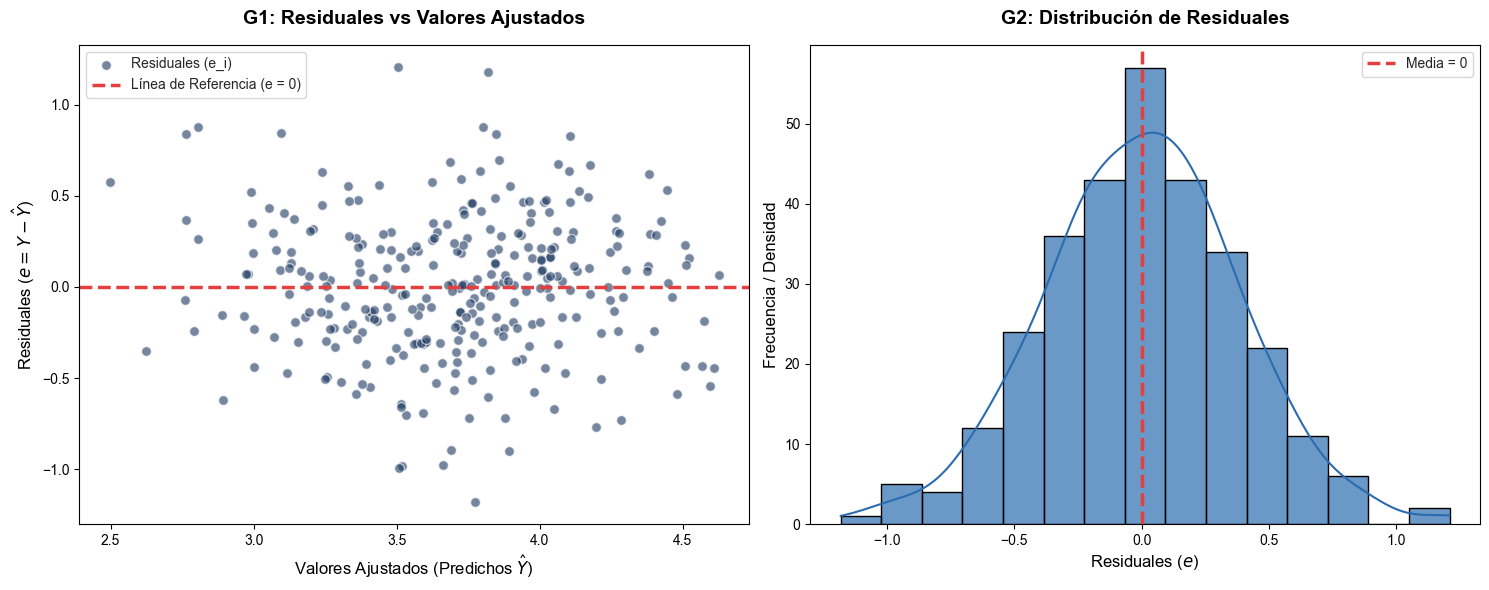

In [ ]:
# 6) Calcular residuales y valores ajustados (predichos)
ajustados = m3.fittedvalues
residuales = m3.resid

# 7) Generar las gráficas G1 y G2 de forma premium
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Estilo de visualización agradable
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# G1: Residuales vs Ajustados
axes[0].scatter(ajustados, residuales, color='#1A365D', alpha=0.6, edgecolors='w', s=50, label='Residuales (e_i)')
axes[0].axhline(0, color='#E53E3E', linestyle='--', linewidth=2.5, label='Línea de Referencia (e = 0)')
axes[0].set_title('G1: Residuales vs Valores Ajustados', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Valores Ajustados (Predichos $\hat{Y}$)', fontsize=12)
axes[0].set_ylabel('Residuales ($e = Y - \hat{Y}$)', fontsize=12)
axes[0].legend(loc='upper left', frameon=True)
axes[0].tick_params(labelsize=10)

# G2: Histograma de residuales con KDE
import seaborn as sns
sns.histplot(residuales, kde=True, color='#2B6CB0', ax=axes[1], bins=15, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='#E53E3E', linestyle='--', linewidth=2.5, label='Media = 0')
axes[1].set_title('G2: Distribución de Residuales', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Residuales ($e$)', fontsize=12)
axes[1].set_ylabel('Frecuencia / Densidad', fontsize=12)
axes[1].legend(loc='upper right', frameon=True)
axes[1].tick_params(labelsize=10)

plt.tight_layout()
plt.show()

### Análisis de Residuales (Bullets de Diagnóstico)

* **¿Ves patrón (curva/abanico) o se ve “nube” alrededor de 0?**  
  En el gráfico G1 (Residuales vs. Ajustados), los puntos se distribuyen de manera completamente aleatoria y homogénea, formando una "nube" de puntos simétrica alrededor de la línea horizontal $e = 0$. No hay presencia de curvatura (lo que descarta problemas de no linealidad) ni una dispersión que cambie a lo largo del eje X.

* **¿Hay outliers evidentes?**  
  No se aprecian valores atípicos o outliers evidentes en ninguna de las gráficas. Casi la totalidad de los residuales se encuentran confinados dentro de la banda $[-1, 1]$ (aproximadamente a $\pm 2.8$ desviaciones estándar, ya que $\sigma \approx 0.35$), lo cual es enteramente consistente con una distribución de error normal.

* **¿Qué supuesto podría fallar si ves abanico?**  
  Si los residuales mostraran un patrón en forma de abanico (donde la dispersión vertical de los puntos aumenta o disminuye sistemáticamente a medida que aumentan los valores predichos), fallaría el supuesto crítico de homocedasticidad (varianza constante del error). Esto se conoce como *heterocedasticidad*, e implicaría que los errores estándar y p-valores calculados no son confiables, afectando directamente la validez del contraste de hipótesis.

## Parte 4 — Modificación obligatoria

In [ ]:
# 9) Crear horas10 y ajustar el modelo M3b
df['horas10'] = df['horas'] / 10.0
Xb = sm.add_constant(df[['horas10', 'asistencia', 'promedio']])
m3b = sm.OLS(df['nota'], Xb).fit()

# Mostrar la tabla de coeficientes para M3b
print(m3b.summary().tables[1])

=== COEFICIENTES DEL MODELO M3b (Con horas en decenas) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.001       0.274       1.024
horas10        0.4117      0.089      4.610      0.000       0.236       0.587
asistencia     0.0106      0.002      4.817      0.000       0.006       0.015
promedio       0.5753      0.050     11.422      0.000       0.476       0.674


### Comparación de Modelos ($M_3$ vs. $M_{3b}$)

* **Coeficiente de horas ($M_3$)**: $\hat{\beta}_{\text{horas}} = 0.0412$
* **Coeficiente de horas10 ($M_{3b}$)**: $\hat{\beta}_{\text{horas10}} = 0.4117$

#### 1. ¿Por qué cambia el número?
El estimador numérico se multiplica exactamente por 10 al pasar de $M_3$ a $M_{3b}$. Esto se debe a que cambiamos la escala de la variable predictora dividiéndola entre 10 (horas10 = horas / 10). Dado que la unidad de medida ahora es 10 veces más grande (una decena de horas en lugar de una hora individual), el coeficiente debe crecer proporcionalmente por un factor de 10 para representar exactamente el mismo efecto marginal físico sobre la nota, de este modo, se mantiene la equivalencia del modelo.

#### 2. ¿Cómo cambia la interpretación en palabras?
* **Interpretación en $M_3$ (Unidad = 1 hora)**:  
   *“Si las horas de estudio por semana aumentan en 1 hora, la nota esperada aumenta en 0.0412 puntos, manteniendo constantes los demás predictores del modelo.”*

* **Interpretación en $M_{3b}$ (Unidad = 1 decena de horas)**:  
   *“Si las horas10 (decenas de horas de estudio por semana) aumentan en 1 unidad (es decir, 10 horas de estudio adicionales), la nota esperada aumenta en 0.4117 puntos, manteniendo constantes los demás predictores del modelo.”*

## Párrafo Final

Este estudio analizó el impacto simultáneo de tres factores académicos clave sobre el rendimiento académico estudiantil (nota). A partir del modelo ajustado $M_3$, estimamos que por cada hora adicional de estudio semanal, la nota esperada se incrementa en 0.0412 puntos; asimismo, cada punto porcentual adicional en asistencia incrementa la nota esperada en 0.0106 puntos, y un aumento de un punto en el promedio previo se asocia con una ganancia esperada sustancial de 0.5753 puntos (manteniendo fijas las demás variables en cada caso). Las pruebas de significancia individual revelaron que todos los predictores son altamente significativos al 5% (con p-valores menores a $0.001$ e intervalos de confianza del 95% que excluyen holgadamente el cero), corroborando que el promedio previo ostenta el mayor peso e importancia práctica sobre el desempeño actual. La evaluación diagnóstica de los residuales arrojó una distribución normal con media cero y una dispersión aleatoria y homogénea, validando sin reservas el supuesto crítico de homocedasticidad y la idoneidad funcional del modelo de regresión múltiple. Finalmente, al reescalar el estudio del tiempo de estudio a decenas de horas en el modelo $M_{3b}$, el coeficiente se multiplicó exactamente por diez ($\hat{\beta}_{\text{horas10}} = 0.4117$), lo que modifica el valor numérico y la interpretación verbal de la tasa de cambio marginal (que pasa a expresarse por cada bloque de 10 horas de estudio) pero deja inalterada la especificación predictiva y la veracidad de la relación matemática del sistema.